# Homework 6  - Logistic Regression without using any libraries. 

## Your Name Here

Student Name: Leia Nayana Das

Student UT EID: lnd749

---

Partner Name: Javier Diaz de Sandi Viramontes

Partner UT EID: jd52288

---

Date Created: 10/06/25

Date Last Modified: 10/09/25

---

Totoal Points 20. 



In [3]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

# Your allowed to use only the above libraries that are imported. No other libs should be used in this assignment. 

## Heart Dataset 

In this Assignment we will work with some patients dataset. 

We have access to 303 patients data. The features are listed below. 

In [4]:
# Your code here
heart_df = pd.read_csv("Heart.csv")
heart_df

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,Target
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


**Age:** The person’s age in years

**Sex:** The person’s sex (1 = male, 0 = female)

**ChestPain:** chest pain type

* Value 0: asymptomatic
* Value 1: atypical angina
* Value 2: non-anginal pain
* Value 3: typical angina

**RestBP:** The person’s resting blood pressure (mm Hg on admission to the hospital)

**Chol:** The person’s cholesterol measurement in mg/dl

**Fbs:** The person’s fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false)
restecg: resting electrocardiographic results

* Value 0: showing probable or definite left ventricular hypertrophy by Estes’ criteria
* Value 1: normal
* Value 2: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)

**RestECG:** The person’s maximum heart rate achieved

**MaxHR:** Exercise induced angina (1 = yes; 0 = no)

**Oldpeak:** ST depression induced by exercise relative to rest (‘ST’ relates to positions on the ECG plot. See more here)

**Slope:** the slope of the peak exercise ST segment — 0: downsloping; 1: flat; 2: upsloping

* 0: downsloping; 
* 1: flat; 
* 2: upsloping

**Ca:** The number of major vessels (0–3)

**Thal:** A blood disorder called thalassemia Value 0: NULL (dropped from the dataset previously

* Value 1: fixed defect (no blood flow in some part of the heart)
* Value 2: normal blood flow
* Value 3: reversible defect (a blood flow is observed but it is not normal)

**Target:** Heart disease (1 = no, 0= yes)

# Task 1 - (4 points)
We want to use logistic regerssion to predict if a patient will have heart problems or not. The column "Target" in our datasets includes data about heart disease. If the patient had heart disease, the patient's "Target" value equals 1. Otherwise, "Target" equals 0.

Prepare your data set for predicting heart disease ("Target" column) by using 3 features:

* Age of the patient (Column **"Age"**)
* Gender of the patient (male or female - Column **"Sex"**)
* Cholestrol level of the patient (Column **"Chol"**) 

Split your data into 80% traning data and 20% test data ***without*** using any libraries other than the ones imported above. You must do it manually.

* Do a maximum of **100 iterations**
* Use a very small learning rate for checking your GD implementation. 
* Your are allowed to use your choice of learning rate, like using 0.0001, 0.001 or 0.01 or 0.1 or higher/lower. 
* **Visualize your error/costs over the iterations with a plot**.
* No need to add an y-intercept in this task. 

(**4 points** - 3 points for code, 1 point for cost visualization)

array([0.74886685, 0.32977345, 0.95923847])

Iteration 0, Cost = 0.693147
Iteration 10, Cost = 0.670904
Iteration 20, Cost = 0.656517
Iteration 30, Cost = 0.647086
Iteration 40, Cost = 0.640805
Iteration 50, Cost = 0.636555
Iteration 60, Cost = 0.633640
Iteration 70, Cost = 0.631615
Iteration 80, Cost = 0.630193
Iteration 90, Cost = 0.629185


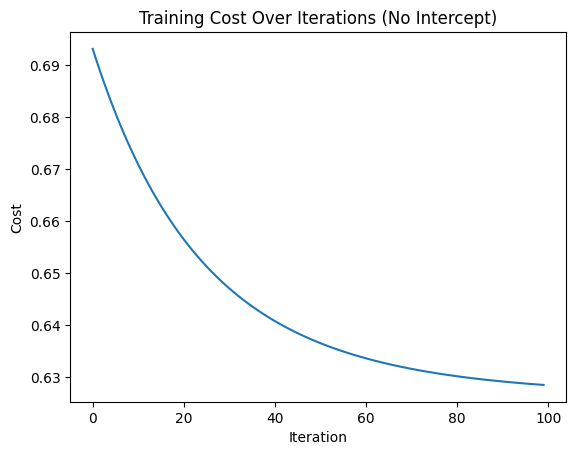

Final Weights: [0.45874808 0.52633818 0.11666608]


In [14]:
# classify target as No = 0 and Yes = 1
targetClass = {"Yes": 1, "No": 0}
heart_df = heart_df.replace({"Target": targetClass})

# prepare X and y and normalize
features = ["Age", "Sex", "Chol"]

# Split manually into training and testing (80/20)
training = heart_df.sample(frac=0.8)
testing = heart_df.drop(training.index)

# Build numpy arrays for training
X_train = training[features].copy()
X_train = (X_train - X_train.mean()) / X_train.std()
X_train = X_train.values
y_train = training['Target'].values.astype(float)

# Build numpy arrays for testing
X_test = testing[features].copy()
X_test = (X_test - X_test.mean()) / X_test.std()
X_test = X_test.values
y_test = testing['Target'].values.astype(float)

# Initialize weight guesses
np.random.seed(0)
weights = np.zeros(X_train.shape[1])


def sigmoid(z):
    g = 1 / (1 + np.exp(-z))
    return g

def cost_function(X, y, weights):
    n, d = X.shape
    xDotWeights = X.dot(weights)

    cost = 1.0 / n * (-y.T.dot(np.log(sigmoid(xDotWeights))) - (1 - y).T.dot(np.log(1 - sigmoid(xDotWeights))))

    return cost

def gradient(X, y, weights):
    n, d = X.shape
    x_dot_weights = X.dot(weights)

    grad = (1.0 / n )* (sigmoid(x_dot_weights) - y).T.dot(X)

    return grad

# Initialize parameters
num_iterations = 100
learningRate = 0.1
cost_list = []

# Logistic Regression
for i in range(num_iterations):
    cost = cost_function(X_train, y_train, weights)
    cost_list.append(cost)

    grad = gradient(X_train, y_train, weights)
    weights = weights - learningRate * grad

    # if i % 10 == 0:
    #     print(f"Iteration {i}, Cost = {cost:.6f}")

# Plot cost over iterations
plt.plot(np.arange(len(cost_list)), cost_list)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Training Cost Over Iterations (No Intercept)')
plt.show()

print('Final Weights:', weights)


# Task 2 - (4 points)

Cacluate the Accuracy, Precision, Recall and F1 score of your logistic regression implementaion on the testing set. 
Print the results. 

You may use equations shown in lecture/slides/examples.

Calcuate the accuracy, precision, recall and F1 score of your logistic regression implementaion on the testing set. 
Print the results. (**4 points**)


In [48]:
TP = 0
TN = 0
FP = 0
FN = 0
y_pred = np.zeros(len(y_test))

for i in range(len(y_test)):
    y_predElement = X_test[i][0]*weights[0] + X_test[i][1]*weights[1] + X_test[i][2]*weights[2]
    if y_predElement > 0:
        y_predElement = 1
    else:
        y_predElement = 0
    y_pred[i] = y_predElement
    if (y_test[i] == 1) & (y_pred[i] == 1):
        TP += 1
    elif (y_test[i] == 0) & (y_pred[i] == 1):
        FP += 1
    elif (y_test[i] == 1) & (y_pred[i] == 0):
        FN += 1
    else:
        TN += 1

accuracy = (TP + TN) / len(y_test)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
F1_Score = 2 * ((precision*recall)/(precision+recall))

print(TP,FP,FP,TN)

print(f"Accuracy is: {round(accuracy*100,2)}%")
print(f"Precision is: {round(precision*100,2)}%")
print(f"Recall is: {round(recall*100,2)}%")
print(f"F1 Score is: {round(F1_Score*100,2)}%")

18 9 9 25
Accuracy is: 70.49%
Precision is: 66.67%
Recall is: 66.67%
F1 Score is: 66.67%


# Task 3 - (4 points)

Add a y-intercept and repeat the above tasks. Do you see any differences after adding the y-intercept?

(4 points - 2 for code, 1 for cost visualizaiton, 1 for description.)

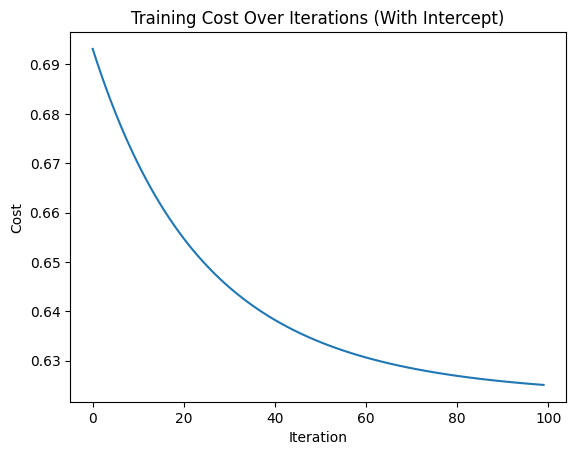

Final Weights: [-0.15022885  0.4608069   0.53098014  0.1180287 ]
17 8 8 26
Accuracy is: 70.49%
Precision is: 68.0%
Recall is: 62.96%
F1 Score is: 65.38%


In [49]:
# classify target as No = 0 and Yes = 1
targetClass = {"Yes": 1, "No": 0}
heart_df = heart_df.replace({"Target": targetClass})

# prepare X and y and normalize
features = ["Age", "Sex", "Chol"]

# Split manually into training and testing (80/20)
training = heart_df.sample(frac=0.8)
testing = heart_df.drop(training.index)

# Build pandas DataFrame for training
X_train_df = training[features].copy()
# compute training mean/std and normalize training set
train_mean = X_train_df.mean()
train_std = X_train_df.std()
X_train = (X_train_df - train_mean) / train_std

# Add intercept column (ones) as the first column
X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train.values])
y_train = training['Target'].values.astype(float)

# Build pandas DataFrame for testing and normalize using training statistics
X_test_df = testing[features].copy()
X_test_norm = (X_test_df - train_mean) / train_std
X_test = np.hstack([np.ones((X_test_norm.shape[0], 1)), X_test_norm.values])
y_test = testing['Target'].values.astype(float)

# Initialize weight guesses (now includes intercept)
np.random.seed(0)
weights = np.zeros(X_train.shape[1])


def sigmoid(z):
    g = 1 / (1 + np.exp(-z))
    return g

def cost_function(X, y, weights):
    n, d = X.shape
    xDotWeights = X.dot(weights)

    cost = 1.0 / n * (-y.T.dot(np.log(sigmoid(xDotWeights))) - (1 - y).T.dot(np.log(1 - sigmoid(xDotWeights))))

    return cost

def gradient(X, y, weights):
    n, d = X.shape
    x_dot_weights = X.dot(weights)

    grad = (1.0 / n )* (sigmoid(x_dot_weights) - y).T.dot(X)

    return grad

# Initialize parameters
num_iterations = 100
learningRate = 0.1
cost_list = []

# Logistic Regression (with intercept)
for i in range(num_iterations):
    cost = cost_function(X_train, y_train, weights)
    cost_list.append(cost)
    grad = gradient(X_train, y_train, weights)
    weights = weights - learningRate * grad

    # if i % 10 == 0:
    #     print(f"Iteration {i}, Cost = {cost:.6f}")

# Plot cost over iterations
plt.plot(np.arange(len(cost_list)), cost_list)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Training Cost Over Iterations (With Intercept)')
plt.show()

# print('Final Weights:', weights)

TP = 0
TN = 0
FP = 0
FN = 0
y_pred = np.zeros(len(y_test))

for i in range(len(y_test)):
    y_predElement = X_test[i][0]*weights[0] + X_test[i][1]*weights[1] + X_test[i][2]*weights[2]
    if y_predElement > 0:
        y_predElement = 1
    else:
        y_predElement = 0
    y_pred[i] = y_predElement
    if (y_test[i] == 1) & (y_pred[i] == 1):
        TP += 1
    elif (y_test[i] == 0) & (y_pred[i] == 1):
        FP += 1
    elif (y_test[i] == 1) & (y_pred[i] == 0):
        FN += 1
    else:
        TN += 1

accuracy = (TP + TN) / len(y_test)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
F1_Score = 2 * ((precision*recall)/(precision+recall))

# print(TP,FP,FP,TN)

print(f"Accuracy is: {round(accuracy*100,2)}%")
print(f"Precision is: {round(precision*100,2)}%")
print(f"Recall is: {round(recall*100,2)}%")
print(f"F1 Score is: {round(F1_Score*100,2)}%")


After comparing the results of the Gradient Descent before and after adding the y-intercept, it can be seen that adding the y-intercept changed the weights of the equation slightly, increased our precision, and decreased our recall and F1 score.

# Task 4 - Implement the Bold Driver   - (4 points)

Implement the bold driver into your gradient descent implementation, which lets us have a dynamic learning rate. Visualize the costs and print the accuracy/etc. metrics as before. Do not use a y-intercept this time.

Add a stop condition that stop the GD when the cost is not changing more than 0.001 between iterations. 
Describe the results. Did you stop earlier than 100 iterations?
(4 points - 2 for code, 1 for cost visualizaiton, 1 for description.)



Stopped at iteration 24


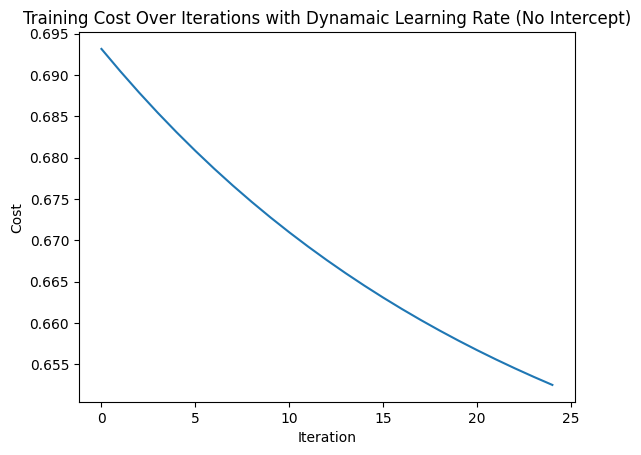

Accuracy is: 70.49%
Precision is: 65.52%
Recall is: 70.37%
F1 Score is: 67.86%


In [60]:
# classify target as No = 0 and Yes = 1
targetClass = {"Yes": 1, "No": 0}
heart_df = heart_df.replace({"Target": targetClass})

# prepare X and y and normalize
features = ["Age", "Sex", "Chol"]

# Split manually into training and testing (80/20)
training = heart_df.sample(frac=0.8)
testing = heart_df.drop(training.index)

# Build numpy arrays for training
X_train = training[features].copy()
X_train = (X_train - X_train.mean()) / X_train.std()
X_train = X_train.values
y_train = training['Target'].values.astype(float)

# Build numpy arrays for testing
X_test = testing[features].copy()
X_test = (X_test - X_test.mean()) / X_test.std()
X_test = X_test.values
y_test = testing['Target'].values.astype(float)

# Initialize weight guesses
np.random.seed(0)
weights = np.zeros(X_train.shape[1])


def sigmoid(z):
    g = 1 / (1 + np.exp(-z))
    return g

def cost_function(X, y, weights):
    n, d = X.shape
    xDotWeights = X.dot(weights)

    cost = 1.0 / n * (-y.T.dot(np.log(sigmoid(xDotWeights))) - (1 - y).T.dot(np.log(1 - sigmoid(xDotWeights))))

    return cost

def gradient(X, y, weights):
    n, d = X.shape
    x_dot_weights = X.dot(weights)

    grad = (1.0 / n )* (sigmoid(x_dot_weights) - y).T.dot(X)

    return grad

# Initialize parameters
num_iterations = 100
learningRate = 0.1
decayRate = 0.001
oldCost = float('inf')
cost_list = []
prec = 0.001

# Logistic Regression
for i in range(num_iterations):
    cost = cost_function(X_train, y_train, weights)
    cost_list.append(cost)

    if abs(cost - oldCost) <= prec:
        print("Stopped at iteration", i)
        break

    grad = gradient(X_train, y_train, weights)
    weights = weights - learningRate * grad

    learningRate = 0.1 * np.exp(-decayRate*i)

    oldCost = cost
    # if i % 10 == 0:
    #     print(f"Iteration {i}, Cost = {cost:.6f}")

# Plot cost over iterations
plt.plot(np.arange(len(cost_list)), cost_list)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Training Cost Over Iterations with Dynamaic Learning Rate (No Intercept)')
plt.show()

# print('Final Weights:', weights)

TP = 0
TN = 0
FP = 0
FN = 0
y_pred = np.zeros(len(y_test))

for i in range(len(y_test)):
    y_predElement = X_test[i][0]*weights[0] + X_test[i][1]*weights[1] + X_test[i][2]*weights[2]
    if y_predElement > 0:
        y_predElement = 1
    else:
        y_predElement = 0
    y_pred[i] = y_predElement
    if (y_test[i] == 1) & (y_pred[i] == 1):
        TP += 1
    elif (y_test[i] == 0) & (y_pred[i] == 1):
        FP += 1
    elif (y_test[i] == 1) & (y_pred[i] == 0):
        FN += 1
    else:
        TN += 1

accuracy = (TP + TN) / len(y_test)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
F1_Score = 2 * ((precision*recall)/(precision+recall))

# print(TP,FP,FP,TN)

print(f"Accuracy is: {round(accuracy*100,2)}%")
print(f"Precision is: {round(precision*100,2)}%")
print(f"Recall is: {round(recall*100,2)}%")
print(f"F1 Score is: {round(F1_Score*100,2)}%")

As seen in the graph, the simulation stopped way earlier than 100 iterations.

# Task 5 - Implement the L2 norm regularization.  - (4 points)



Modify your Cost and gradient to implement the l2 norm regularization. Repeat the steps taken in prior tasks and describe your result.

 * Use a y-intercept.
 * Do a maximum of 100 iterations as before and report your accuracy, precision, recall and F1 score.
 * Optional: You can stop earlier, if the cost is not changing more than 0.001 between iterations.
 * Optional: You can use the bold driver, if you want. But a bold driver is not required to perform L2 norm regularizaiton.

(4 points - 2 for code, 1 for cost visualizaiton, 1 for description.)

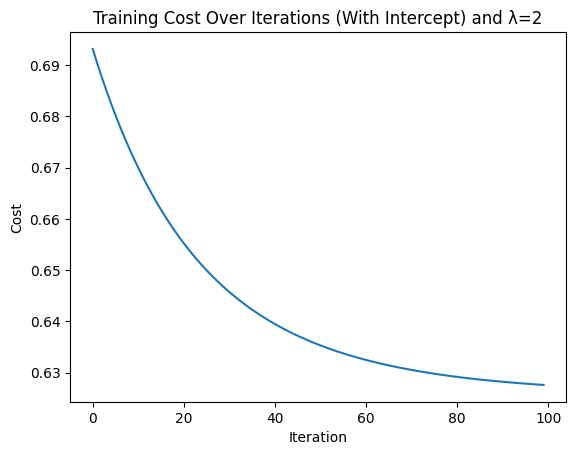

Accuracy is: 70.49%
Precision is: 68.0%
Recall is: 62.96%
F1 Score is: 65.38%


In [16]:
# classify target as No = 0 and Yes = 1
targetClass = {"Yes": 1, "No": 0}
heart_df = heart_df.replace({"Target": targetClass})

# prepare X and y and normalize
features = ["Age", "Sex", "Chol"]

# Split manually into training and testing (80/20)
training = heart_df.sample(frac=0.8)
testing = heart_df.drop(training.index)

# Build pandas DataFrame for training
X_train_df = training[features].copy()
# compute training mean/std and normalize training set
train_mean = X_train_df.mean()
train_std = X_train_df.std()
X_train = (X_train_df - train_mean) / train_std

# Add intercept column (ones) as the first column
X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train.values])
y_train = training['Target'].values.astype(float)

# Build pandas DataFrame for testing and normalize using training statistics
X_test_df = testing[features].copy()
X_test_norm = (X_test_df - train_mean) / train_std
X_test = np.hstack([np.ones((X_test_norm.shape[0], 1)), X_test_norm.values])
y_test = testing['Target'].values.astype(float)

# Initialize weight guesses (now includes intercept)
np.random.seed(0)
weights = np.zeros(X_train.shape[1])


def sigmoid(z):
    g = 1 / (1 + np.exp(-z))
    return g

def cost_function(X, y, weights, regLambda):
    n, d = X.shape
    xDotWeights = X.dot(weights)

    num = len(y)

    cost_1 = 1.0 / n * (-y.T.dot(np.log(sigmoid(xDotWeights))) - (1 - y).T.dot(np.log(1 - sigmoid(xDotWeights))))
    wReg = weights.copy()
    wReg[0] = 0.0
    cost_2 = (regLambda/(2.0 * num))* np.sum(wReg**2)

    cost = cost_1 + cost_2

    return cost

def gradient(X, y, weights, regLambda):
    n, d = X.shape
    x_dot_weights = X.dot(weights)

    num = len(y)

    grad_1 = (1.0 / n )* (sigmoid(x_dot_weights) - y).T.dot(X)
    wReg = weights.copy()
    wReg[0] = 0.0
    grad_2 = (regLambda/num)* wReg

    grad = grad_1 + grad_2

    return grad

# Initialize parameters
regLambda = 2
num_iterations = 100
learningRate = 0.1
cost_list = []

# Logistic Regression (with intercept)
for i in range(num_iterations):
    cost = cost_function(X_train, y_train, weights, regLambda)
    cost_list.append(cost)
    grad = gradient(X_train, y_train, weights, regLambda)
    weights = weights - learningRate * grad

    # if i % 10 == 0:
    #     print(f"Iteration {i}, Cost = {cost:.6f}")

# Plot cost over iterations
plt.plot(np.arange(len(cost_list)), cost_list)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title(f'Training Cost Over Iterations (With Intercept) and λ={regLambda}')
plt.show()

# print('Final Weights:', weights)

TP = 0
TN = 0
FP = 0
FN = 0
y_pred = np.zeros(len(y_test))

for i in range(len(y_test)):
    y_predElement = X_test[i][0]*weights[0] + X_test[i][1]*weights[1] + X_test[i][2]*weights[2]
    if y_predElement > 0:
        y_predElement = 1
    else:
        y_predElement = 0
    y_pred[i] = y_predElement
    if (y_test[i] == 1) & (y_pred[i] == 1):
        TP += 1
    elif (y_test[i] == 0) & (y_pred[i] == 1):
        FP += 1
    elif (y_test[i] == 1) & (y_pred[i] == 0):
        FN += 1
    else:
        TN += 1

accuracy = (TP + TN) / len(y_test)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
F1_Score = 2 * ((precision*recall)/(precision+recall))

# print(TP,FP,FP,TN)

print(f"Accuracy is: {round(accuracy*100,2)}%")
print(f"Precision is: {round(precision*100,2)}%")
print(f"Recall is: {round(recall*100,2)}%")
print(f"F1 Score is: {round(F1_Score*100,2)}%")

After comparing the results of the Gradient Descent before and after adding the L2 norm regularization, it can be seen that adding the L2 norm regularization changed the weights of the equation slightly, increased our precision, and decreased our recall and F1 score.